In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
sys.path.append('./')  # uncomment for local import
import tangram as tg

%load_ext autoreload
%autoreload 2
%matplotlib inline

tg.__version__

'1.0.4'

In [2]:
#Load spatial
path = os.path.join('./data', 'mLung_O1_st.h5ad')
ad_sp = sc.read_h5ad(path)
ad_sp.var

,name
NA,1810065E05Rik
NA.1,2210010C04Rik
NA.2,2610528A11Rik
AA467197,AA467197
NA.3,Abhd12
...,...
NA.882,Wnt2
NA.883,Wnt9a
NA.884,Xist
NA.885,Zg16


In [3]:
ad_sp.var_names = ad_sp.var['name']
ad_sp.var.head()


,name
name,
1810065E05Rik,1810065E05Rik
2210010C04Rik,2210010C04Rik
2610528A11Rik,2610528A11Rik
AA467197,AA467197
Abhd12,Abhd12


In [4]:
ad_sp.obs['final.annotation']

3                 AT 2 cells
6                 AT 2 cells
10                AT 2 cells
11                AT 2 cells
13         Endothelial cells
                ...         
22640             AT 2 cells
22643             AT 2 cells
22644             AT 2 cells
22646      Endothelial cells
22650    Smooth muscle cells
Name: final.annotation, Length: 11880, dtype: category
Categories (16, object): ['AT 1 cells', 'AT 2 cells', 'B cells', 'Club cells', ..., 'Monocytes', 'Red blood cells', 'Smooth muscle cells', 'T cells']

In [5]:
#Load single cell
path = os.path.join('data','mLung_sc.h5ad')
ad_sc = sc.read_h5ad(path)
ad_sc

AnnData object with n_obs × n_vars = 35474 × 20055
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'pANN_0.25_0.25_412', 'DF.classifications_0.25_0.25_412', 'percent.mt', 'pANN_0.25_0.26_453', 'DF.classifications_0.25_0.26_453', 'pANN_0.25_0.19_503', 'DF.classifications_0.25_0.19_503', 'pANN_0.25_0.12_464', 'DF.classifications_0.25_0.12_464', 'pANN_0.25_0.28_460', 'DF.classifications_0.25_0.28_460', 'pANN_0.25_0.27_489', 'DF.classifications_0.25_0.27_489', 'percent.ribo', 'integrated_snn_res.0.8', 'seurat_clusters', 'predicted.id', 'prediction.score.B.cell', 'prediction.score.non.classical.monocyte', 'prediction.score.natural.killer.cell', 'prediction.score.alveolar.macrophage', 'prediction.score.myeloid.dendritic.cell', 'prediction.score.CD8.positive..alpha.beta.T.cell', 'prediction.score.classical.monocyte', 'prediction.score.bronchial.smooth.muscle.cell', 'prediction.score.mature.NK.T.cell', 'prediction.score.T.cell', 'prediction.score.pulmonary.interstitial.fibroblast', 'predi

In [6]:
#Subset scRNA-seq
specific_value = 'mLung_O1'
ad_sc_subset1 = ad_sc[ad_sc.obs['orig.ident'] == specific_value]
ad_sc_subset1.var

,name
Xkr4,Xkr4
Gm1992,Gm1992
Gm37381,Gm37381
Rp1,Rp1
Sox17,Sox17
...,...
Gm11337,Gm11337
Anxa13,Anxa13
Tmem207,Tmem207
Vmn2r118,Vmn2r118


In [7]:
ad_sc_subset1

View of AnnData object with n_obs × n_vars = 5249 × 20055
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'pANN_0.25_0.25_412', 'DF.classifications_0.25_0.25_412', 'percent.mt', 'pANN_0.25_0.26_453', 'DF.classifications_0.25_0.26_453', 'pANN_0.25_0.19_503', 'DF.classifications_0.25_0.19_503', 'pANN_0.25_0.12_464', 'DF.classifications_0.25_0.12_464', 'pANN_0.25_0.28_460', 'DF.classifications_0.25_0.28_460', 'pANN_0.25_0.27_489', 'DF.classifications_0.25_0.27_489', 'percent.ribo', 'integrated_snn_res.0.8', 'seurat_clusters', 'predicted.id', 'prediction.score.B.cell', 'prediction.score.non.classical.monocyte', 'prediction.score.natural.killer.cell', 'prediction.score.alveolar.macrophage', 'prediction.score.myeloid.dendritic.cell', 'prediction.score.CD8.positive..alpha.beta.T.cell', 'prediction.score.classical.monocyte', 'prediction.score.bronchial.smooth.muscle.cell', 'prediction.score.mature.NK.T.cell', 'prediction.score.T.cell', 'prediction.score.pulmonary.interstitial.fibroblast',

In [8]:
#Normalize sc
sc.pp.normalize_total(ad_sc_subset1)
#Normalize sp
sc.pp.normalize_total(ad_sp)
ad_sc_subset1.obs['final.annotation'].value_counts()

final.annotation
Alveolar type 2 cell 1                714
Mesenchymal cell 1                    400
Macrophage 1                          374
Fibroblast 2                          368
Alveolar type 1 cell 1                323
B cell 1                              294
Club cell 1                           250
Red blood cell 1                      229
Alveolar type 2 cell 2                208
Endothelial cell 1                    206
Fibroblast 1                          197
Club cell 2                           172
Lipofibroblast 1                      170
T cell 1                              169
Ciliated cell 1                       153
Monocyte 2                            149
Smooth muscle cell 2                  126
Endothelial cell 5                    106
Endothelial cell 4                     97
Krt4/Krt13 Epithelial cell state 1     87
Endothelial cell 3                     85
Dendritic cell 1                       79
Alveolar type 1 cell 2                 63
Endothelial cell 

In [9]:
#Marker genes for mapping sc to st
df_genes = pd.read_csv('~/Tangram/data/genes.csv', index_col=0)
markers = np.reshape(df_genes.values, (-1, ))
markers = list(markers)
len(markers)

890

In [10]:
#Prepare training_genes
tg.pp_adatas(ad_sc_subset1, ad_sp, genes=markers)

INFO:root:788 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
INFO:root:788 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
INFO:root:uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
INFO:root:rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.


In [11]:
cv_dict, ad_ge_cv, df = tg.cross_val(ad_sc_subset1, 
                                     ad_sp, 
                                     device='cuda:0', 
                                     mode='clusters',
                                     cv_mode='loo',
                                     num_epochs=1000,
                                     cluster_label='final.annotation',
                                     return_gene_pred=True,
                                     verbose=False,
                                     )

100%|██████████| 788/788 [4:58:54<00:00, 22.76s/it]  

cv avg test score 0.081
cv avg train score 0.173


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score, f1_score

# -------------------------------
# Step 1: common genes
# -------------------------------
common_genes = ad_sp.var_names.intersection(ad_ge_cv.var_names)
print(f"Number of common genes: {len(common_genes)}")

# -------------------------------
# Step 2: identify clusters
# -------------------------------
clusters = ad_sp.obs['final.annotation'].unique()
print(f"Clusters: {clusters}")

# -------------------------------
# Step 3: aggregate expression per cluster
# -------------------------------
true_agg = pd.DataFrame(index=clusters, columns=common_genes)
pred_agg = pd.DataFrame(index=clusters, columns=common_genes)

for g in common_genes:
    for c in clusters:
        true_vals = ad_sp[ad_sp.obs['final.annotation']==c, g].X
        pred_vals = ad_ge_cv[ad_sp.obs['final.annotation']==c, g].X

        # convert sparse -> dense
        if hasattr(true_vals, "toarray"):
            true_vals = true_vals.toarray().flatten()
        else:
            true_vals = np.asarray(true_vals).flatten()
        if hasattr(pred_vals, "toarray"):
            pred_vals = pred_vals.toarray().flatten()
        else:
            pred_vals = np.asarray(pred_vals).flatten()

        # sum per cluster
        true_agg.loc[c, g] = true_vals.sum()
        pred_agg.loc[c, g] = pred_vals.sum()

# convert to numeric
true_agg = true_agg.astype(float)
pred_agg = pred_agg.astype(float)

# -------------------------------
# Step 4: compute per-gene metrics (cluster-aggregated)
# -------------------------------
results_cluster = {
    'Spearman': [],
    'Cosine': [],
    'AUC': []
}

for g in common_genes:
    t = true_agg[g].values
    p = pred_agg[g].values

    # Spearman
    if np.std(t) > 0 and np.std(p) > 0:
        results_cluster['Spearman'].append(spearmanr(t, p).correlation)
    else:
        results_cluster['Spearman'].append(np.nan)

    # Cosine similarity
    sim = cosine_similarity(t.reshape(1,-1), p.reshape(1,-1))[0,0]
    results_cluster['Cosine'].append(sim)

    # ROC-AUC (need at least one positive and one zero)
    if np.any(t>0) and np.any(t==0):
        results_cluster['AUC'].append(roc_auc_score(t>0, p))
    else:
        results_cluster['AUC'].append(np.nan)

# convert to DataFrame
results_cluster_df = pd.DataFrame(results_cluster, index=common_genes)
results_cluster_df = results_cluster_df.sort_values('Spearman', ascending=False)

print("Top genes (cluster-aggregated):")
display(results_cluster_df.head())

print("Summary statistics:")
display(results_cluster_df.describe())

Number of common genes: 788
Clusters: ['AT 2 cells', 'Endothelial cells', 'Lipofibroblasts', 'Red blood cells', 'Mesenchymal cells', ..., 'Macrophage', 'Fibroblast', 'B cells', 'AT 1 cells', 'Goblet cells']
Length: 16
Categories (16, object): ['AT 1 cells', 'AT 2 cells', 'B cells', 'Club cells', ..., 'Monocytes', 'Red blood cells', 'Smooth muscle cells', 'T cells']
Top genes (cluster-aggregated):


,Spearman,Cosine,AUC
siglech,0.991176,0.989462,NaN
cdkn2c,0.979412,0.998584,NaN
cd52,0.979412,0.985234,NaN
sdc4,0.976471,0.998734,NaN
wnt2,0.976405,0.995419,1.0


Summary statistics:


,Spearman,Cosine,AUC
count,788.000000,788.000000,389.000000
mean,0.858512,0.954623,0.885014
std,0.092069,0.116125,0.120349
min,-0.444840,0.026660,0.107143
25%,0.814804,0.975346,0.857143
50%,0.879412,0.988142,0.928571
75%,0.914706,0.993434,0.964286
max,0.991176,0.998795,1.000000


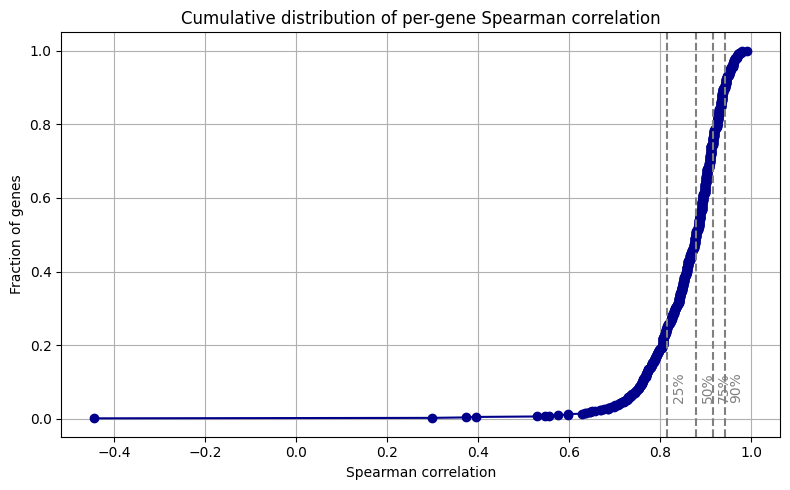

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Get Spearman values, drop NaNs just in case
spearman_vals = results_cluster_df['Spearman'].values

# Sort values
spearman_sorted = np.sort(spearman_vals)

# Compute fraction of genes
fraction_genes = np.arange(1, len(spearman_sorted)+1) / len(spearman_sorted)

# Plot ECDF
plt.figure(figsize=(8,5))
plt.plot(spearman_sorted, fraction_genes, marker='o', linestyle='-', color='darkblue')

# Add percentile lines
for p in [0.25, 0.5, 0.75, 0.9]:
    val = np.quantile(spearman_sorted, p)
    plt.axvline(val, linestyle='--', color='gray')
    plt.text(val+0.01, 0.05, f"{int(p*100)}%", rotation=90, color='gray')

# Labels and grid
plt.xlabel("Spearman correlation")
plt.ylabel("Fraction of genes")
plt.title("Cumulative distribution of per-gene Spearman correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
threshold_25 = results_cluster_df['Spearman'].quantile(0.25)

n_genes_above_25 = (results_cluster_df['Spearman'] > threshold_25).sum()

print(f"25th percentile threshold: {threshold_25}")
print(f"Number of genes above 25th percentile: {n_genes_above_25}")

25th percentile threshold: 0.8148043481262564
Number of genes above 25th percentile: 591
